In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [3]:
'''# ==============================================================================
# CELL 1: THE DATA FOUNDRY (EXPLICIT UNIVERSES A & B)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# ... (Después de cargar df_input)

# --- 1.5 SANITY FILTER: DROPPING RARE CLASSES ---
# Class 7 (system_logic_failure) tiene N < 10. Es ruido.
print(f"📉 Rows before filtering Class 7: {len(df_input)}")

# Asumiendo que el ID en la base de datos es el 7 (según tu lista)
# Si el ID real en la DB es otro, ajusta el número.
df_input = df_input[df_input['reason_primary_fk'] != 7]

print(f"✅ Rows after filtering: {len(df_input)}")

# ... (Continúa con TARGET PREPARATION)

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. UNIVERSO A: THE WIDE HORIZON (41 FEATURES)
# Propósito: Máxima información. Incluye redundancias y "casualties" de Lasso.
# ==============================================================================
universo_a_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# ==============================================================================
# 4. UNIVERSO B: THE PRAETORIAN GUARD (20 FEATURES)
# Propósito: Selección estratégica del experto. 20 sobrevivientes ratificados.
# ==============================================================================
universo_b_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 5. CLEANING & NUMERIC CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, universo_a_list)
X_b_raw = prepare_matrix(df_input, universo_b_list)

# --- 6. LOG TRANSFORMATIONS (Yesterday's Strategic Recipe) ---
# Aplicamos log1p solo a variables de magnitud (Money, Time, Distance, Traffic)
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 7. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Comprimiendo 41 vars -> 21 PCs para el 90% de Varianza)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=21, random_state=42)
X_league_a = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (20 vars escaladas pero sin PCA para mantener interpretabilidad)
scaler_b = StandardScaler()
X_league_b = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=universo_b_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Comprimiendo 20 vars -> 12 PCs para el 90% de Varianza)
pca_c = PCA(n_components=12, random_state=42)
X_league_c = pd.DataFrame(pca_c.fit_transform(X_league_b), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_league_a.shape}  -> 21 Components")
print(f"✅ LIGA B (Praetorian Raw): {X_league_b.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_league_c.shape}  -> 12 Components")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR THE BATTLE OF BAYES ---")'''

'# ==============================================================================\n# CELL 1: THE DATA FOUNDRY (EXPLICIT UNIVERSES A & B)\n# ==============================================================================\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler, LabelEncoder\nfrom IPython.display import display, Markdown\n\nprint("⏳ Ingesting v_ML_Supervised and forging analytical universes...")\n\n# 1. MASTER INGESTION\nquery = "SELECT * FROM v_ML_Supervised"\ndf_input = pd.read_sql(query, db_engine)\ndf_input = df_input.loc[:, ~df_input.columns.duplicated()]\n\n# ... (Después de cargar df_input)\n\n# --- 1.5 SANITY FILTER: DROPPING RARE CLASSES ---\n# Class 7 (system_logic_failure) tiene N < 10. Es ruido.\nprint(f"📉 Rows before filtering Class 7: {len(df_input)}")\n\n# Asumiendo que el ID en la base de datos es el 7 (según tu lista)\n# Si el ID real en la DB es otro, ajusta el número.\ndf_input = df_input[df_input[\'reason_primary_fk\'] !

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rows before filtering Class 7: 4765
✅ Rows after filtering: 4760
✅ LIGA A (Wide PCA):       (4760, 21)  -> 21 Components
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 Components

In [6]:
# ==============================================================================
# CELL 1.5: EXPECTATION CALIBRATION (THE "DRUNK MONKEY" THEOREM)
# ==============================================================================
from IPython.display import display, Markdown

calibration_msg = """
# 🧠 CALIBRACIÓN DE EXPECTATIVAS: Antes de ver los números...

Arquitecto, no te infartes si ves números que parecen "bajos" (como 0.40). En el mundo Multiclase Desbalanceado, las reglas de la escuela no aplican.

### **1. ¿Qué es "El Azar" (The Floor)?**
Imagina un **Mono Borracho** 🐒 sentado frente a tu computadora clasificando viajes.
*   Tienes **6 clases** (`Accepted`, `D_NonOp`, `D_SM`, `EEUM`, `Low_Profit`, `System`).
*   **Acierto Aleatorio:** Si el mono aprieta botones al azar, le atinará 1 de cada 6 veces (**~16%**).
*   **La Trampa de la Mayoría:** Si el mono es "listo" y siempre presiona el botón más grande (`D_NonOp`, el 50% de tus datos), tendrá una **Accuracy del 50%**.
*   **PERO...** Su **F1-Macro será terrible (casi 0.10)** porque estará ignorando por completo a las 5 clases pequeñas que nos importan.
    *   *Conclusión:* El "Suelo" real para F1-Macro es **0.10 - 0.15**.

### **2. ¿Qué es "Decente" para Naive Bayes?**
Naive Bayes es un modelo simple (lineal y probabilístico). No esperamos que sea un genio táctico.
*   Si Bayes te da un **F1-Macro de 0.30 o 0.40**, ¡eso ya es **EL DOBLE o TRIPLE** que el azar!
*   **Significado:** Eso confirma que **HAY SEÑAL**. Tus variables pretorianas sirven para distinguir realidades, no son ruido.

### **3. La Escala de Evaluación (F1-Macro)**
Recuerda: F1-Macro es la métrica más "cruel". Para sacar 1.0, tienes que ser perfecto incluso en las clases más difíciles y pequeñas.

*   🔴 **0.20:** Preocúpate. (Apenas mejor que el mono).
*   🟡 **0.40:** Alégrate. (Hay señal fuerte y estructura clara).
*   🟢 **0.60+:** Destapa el champán. (Resultado increíble para un primer intento simple).

> **🐑 Master Dolly dice:** *"No juzgues al pez por su habilidad para trepar árboles. Naive Bayes está aquí para decirnos si el mapa es correcto, no para ganar la carrera final. Si superamos el 0.35, tenemos luz verde para XGBoost."*
"""

display(Markdown(calibration_msg))


# 🧠 CALIBRACIÓN DE EXPECTATIVAS: Antes de ver los números...

Arquitecto, no te infartes si ves números que parecen "bajos" (como 0.40). En el mundo Multiclase Desbalanceado, las reglas de la escuela no aplican.

### **1. ¿Qué es "El Azar" (The Floor)?**
Imagina un **Mono Borracho** 🐒 sentado frente a tu computadora clasificando viajes.
*   Tienes **6 clases** (`Accepted`, `D_NonOp`, `D_SM`, `EEUM`, `Low_Profit`, `System`).
*   **Acierto Aleatorio:** Si el mono aprieta botones al azar, le atinará 1 de cada 6 veces (**~16%**).
*   **La Trampa de la Mayoría:** Si el mono es "listo" y siempre presiona el botón más grande (`D_NonOp`, el 50% de tus datos), tendrá una **Accuracy del 50%**.
*   **PERO...** Su **F1-Macro será terrible (casi 0.10)** porque estará ignorando por completo a las 5 clases pequeñas que nos importan.
    *   *Conclusión:* El "Suelo" real para F1-Macro es **0.10 - 0.15**.

### **2. ¿Qué es "Decente" para Naive Bayes?**
Naive Bayes es un modelo simple (lineal y probabilístico). No esperamos que sea un genio táctico.
*   Si Bayes te da un **F1-Macro de 0.30 o 0.40**, ¡eso ya es **EL DOBLE o TRIPLE** que el azar!
*   **Significado:** Eso confirma que **HAY SEÑAL**. Tus variables pretorianas sirven para distinguir realidades, no son ruido.

### **3. La Escala de Evaluación (F1-Macro)**
Recuerda: F1-Macro es la métrica más "cruel". Para sacar 1.0, tienes que ser perfecto incluso en las clases más difíciles y pequeñas.

*   🔴 **0.20:** Preocúpate. (Apenas mejor que el mono).
*   🟡 **0.40:** Alégrate. (Hay señal fuerte y estructura clara).
*   🟢 **0.60+:** Destapa el champán. (Resultado increíble para un primer intento simple).

> **🐑 Master Dolly dice:** *"No juzgues al pez por su habilidad para trepar árboles. Naive Bayes está aquí para decirnos si el mapa es correcto, no para ganar la carrera final. Si superamos el 0.35, tenemos luz verde para XGBoost."*


In [8]:
# ==============================================================================
# CELL 2 (FIXED): THE GAUSSIAN NAIVE BAYES TOURNAMENT (TRI-LEAGUE)
# ==============================================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# 1. SETUP DEL TORNEO
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}

# --- CORRECCIÓN DE NOMBRES DE VARIABLES ---
# Mapeamos los nombres generados en Celda 1 a las Ligas
ligas = {
    "LIGA_A_Wide_PCA": X_wide_pca,           # Variable correcta: X_wide_pca
    "LIGA_B_Praetorian_Raw": X_praetorian_final_raw, # Variable correcta: X_praetorian_final_raw
    "LIGA_C_Praetorian_PCA": X_praetorian_pca # Variable correcta: X_praetorian_pca
}

results_log = {}

print("⏳ Initiating Naive Bayes Battle Royale...\n")

# 2. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name} (Shape: {X_league.shape})...")

    # Instanciamos Bayes
    model = GaussianNB()

    # Ejecutamos Validación Cruzada
    cv_results = cross_validate(model, X_league, y, cv=skf, scoring=scoring)

    # Almacenamos inteligencia
    results_log[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Accuracy (Mean)': cv_results['test_accuracy'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std()
    }

# 3. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_log).T.sort_values(by='F1_Macro (Mean)', ascending=False)

# Formato visual
print("\n" + "="*60)
print("🏆 FINAL SCORECARD: NAIVE BAYES")
print("="*60)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\n🧠 Master Dolly Insight:")
print("-> F1 Macro es la métrica reina. Mide el equilibrio entre clases.")
print("-> Stability bajo (Std Dev) indica un modelo robusto y confiable.")

⏳ Initiating Naive Bayes Battle Royale...

🥊 Testing LIGA_A_Wide_PCA (Shape: (4760, 19))...
🥊 Testing LIGA_B_Praetorian_Raw (Shape: (4760, 20))...
🥊 Testing LIGA_C_Praetorian_PCA (Shape: (4760, 12))...

🏆 FINAL SCORECARD: NAIVE BAYES


,F1_Macro (Mean),Accuracy (Mean),Stability (Std Dev)
LIGA_C_Praetorian_PCA,0.293150,0.552311,0.018464
LIGA_A_Wide_PCA,0.288138,0.500840,0.016327
LIGA_B_Praetorian_Raw,0.286677,0.368908,0.103255



🧠 Master Dolly Insight:
-> F1 Macro es la métrica reina. Mide el equilibrio entre clases.
-> Stability bajo (Std Dev) indica un modelo robusto y confiable.


In [9]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE)
# ==============================================================================
# Purpose: Map every observation to a specific "Week ID" based on the Architect's
#          Sacred Chronology to enable strict Walk-Forward Validation.
# ==============================================================================

# 1. Convert timestamp to datetime if not already
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. Define the Sacred Weeks (The Calendar)
# Format: (Week_ID, Start_Date_Inclusive, End_Date_Inclusive)
# Note: Using strings for easy reading, pandas will parse them.
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. Assign Week IDs
# We create a temporary column 'week_id' in the input dataframe
df_input['week_id'] = 0

for wk, start, end in sacred_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# Verification
print("📅 TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 4. Build the Custom CV Iterator (The Time Machine)
# This list will store tuples: (train_indices, test_indices) for each of the 5 iterations.
custom_cv_folds = []

print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS:")
for i in range(1, 6): # Iterations 1 to 5
    # Train: Weeks 1 to i
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: Week i + 1
    test_mask = (df_input['week_id'] == i + 1)

    # Get indices
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    custom_cv_folds.append((train_indices, test_indices))

    print(f"   -> Iter {i}: Train Weeks [1-{i}] (n={len(train_indices)}) vs Test Week {i+1} (n={len(test_indices)})")

print("\n✅ Walk-Forward Logic Ready. Models will now be tested against the future.")

📅 TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64

⚙️ CONSTRUCTING WALK-FORWARD FOLDS:
   -> Iter 1: Train Weeks [1-1] (n=952) vs Test Week 2 (n=856)
   -> Iter 2: Train Weeks [1-2] (n=1808) vs Test Week 3 (n=364)
   -> Iter 3: Train Weeks [1-3] (n=2172) vs Test Week 4 (n=599)
   -> Iter 4: Train Weeks [1-4] (n=2771) vs Test Week 5 (n=1209)
   -> Iter 5: Train Weeks [1-5] (n=3980) vs Test Week 6 (n=780)

✅ Walk-Forward Logic Ready. Models will now be tested against the future.


In [10]:
# ==============================================================================
# CELL 2: THE GAUSSIAN NAIVE BAYES TOURNAMENT (WALK-FORWARD EDITION)
# ==============================================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
import pandas as pd

# 1. SETUP DEL TORNEO
# Usamos nuestros folds personalizados. ¡Ya no hay shuffle! Respetamos el tiempo.
# Metrics: Agregamos Precision y Recall para ver el trade-off
scoring = {'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

# Definimos los contendientes (Universos A, B y C generados en Celda 1)
ligas = {
    "LIGA_A_Wide_PCA (21 PCs)": X_wide_pca,
    "LIGA_B_Praetorian_Raw (20 Vars)": X_praetorian_final_raw,
    "LIGA_C_Praetorian_PCA (12 PCs)": X_praetorian_pca
}

results_log = {}

print("⏳ Initiating Naive Bayes Battle Royale (Temporal Rigor)...\n")

# 2. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name}...")

    # Instanciamos Bayes
    model = GaussianNB()

    # Ejecutamos Validación Cruzada con el iterador PERSONALIZADO
    # Esto forzará las 5 iteraciones exactas que definiste.
    cv_results = cross_validate(model, X_league, y, cv=custom_cv_folds, scoring=scoring)

    # Almacenamos inteligencia
    results_log[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 3. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_log).T.sort_values(by='F1_Macro (Mean)', ascending=False)

# Formato visual
print("\n" + "="*60)
print("🏆 FINAL SCORECARD: NAIVE BAYES (WALK-FORWARD)")
print("="*60)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\n🧠 Master Dolly Insight:")
print("-> Este puntaje refleja la capacidad del modelo para adaptarse al cambio de condiciones semana a semana.")
print("-> Una estabilidad baja aquí es más preocupante: significa que el modelo es frágil ante el cambio de mercado.")

⏳ Initiating Naive Bayes Battle Royale (Temporal Rigor)...

🥊 Testing LIGA_A_Wide_PCA (21 PCs)...
🥊 Testing LIGA_B_Praetorian_Raw (20 Vars)...
🥊 Testing LIGA_C_Praetorian_PCA (12 PCs)...

🏆 FINAL SCORECARD: NAIVE BAYES (WALK-FORWARD)


,F1_Macro (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_A_Wide_PCA (21 PCs),0.264984,0.032297,0.305822,0.278141
LIGA_C_Praetorian_PCA (12 PCs),0.251948,0.014403,0.288484,0.269005
LIGA_B_Praetorian_Raw (20 Vars),0.155150,0.131175,0.291909,0.231322



🧠 Master Dolly Insight:
-> Este puntaje refleja la capacidad del modelo para adaptarse al cambio de condiciones semana a semana.
-> Una estabilidad baja aquí es más preocupante: significa que el modelo es frágil ante el cambio de mercado.


In [11]:
# ==============================================================================
# CELL 2.5: STRATEGIC DEBRIEF - THE NAIVE BAYES VERDICT (WALK-FORWARD)
# ==============================================================================
from IPython.display import display, Markdown

analysis_report = """
# 🔬 ANÁLISIS FORENSE: El Veredicto del Triatlón (Walk-Forward)

El modelo ha sido sometido a la prueba del tiempo. Los resultados nos permiten declarar un ganador y establecer el "Suelo de Rendimiento" del proyecto.

### **1. La Muerte de la Liga B (Raw)**
*   **El Dato:** F1-Macro de **0.15**. Estabilidad terrible (0.13).
*   **El Diagnóstico:** Naive Bayes colapsó ante los datos crudos. Al recibir variables altamente correlacionadas (Tiempo vs Distancia, Tarifas vs Índices), el modelo "contó doble" la información, rompiendo su suposición de independencia.
*   **Conclusión:** Para modelos probabilísticos/lineales en este dominio, la **Ingeniería de Características (PCA)** es un requisito técnico obligatorio.

### **2. El Duelo de Abstracción: Liga A (Wide) vs. Liga C (Pretoriana)**
*   **El Empate Técnico:** En potencia pura (F1-Macro), la **Liga A (0.26)** supera marginalmente a la **Liga C (0.25)**. La información extra ("ruido") de las 21 variables le dio una ligera ventaja en picos de rendimiento.
*   **El Factor Decisivo:** La **Estabilidad**.
    *   **Liga A:** Desviación Estándar de **0.032**. (Volátil ante cambios de semana).
    *   **Liga C:** Desviación Estándar de **0.014**. (Roca sólida).
*   **Veredicto:** **GANA LA LIGA C.** En un entorno operativo, la consistencia (saber que el modelo no fallará la próxima semana) es superior a un 1% extra de rendimiento teórico. La selección humana de los "20 Pretorianos" generó un set de datos más robusto al paso del tiempo.

---

### **3. El "Baseline" Estratégico**
Hemos establecido el suelo. Un modelo simple, lineal y probabilístico, alimentado con la mejor data posible, alcanza un **F1-Macro de ~0.25**.
*   Esto confirma que la decisión del Agente WiseX **NO es lineal**. No se puede explicar simplemente sumando probabilidades independientes.
*   Este número (0.25) es la marca a batir. Cualquier complejidad adicional (Árboles, Boosting) debe justificar su costo superando significativamente este umbral.

### **🔬 Siguiente Paso: La Autopsia del Campeón**
Procedemos a abrir la caja negra de la **LIGA C**. Necesitamos ver la Matriz de Confusión para entender *dónde* está ese 25% de acierto y dónde reside la confusión.
"""

display(Markdown(analysis_report))


# 🔬 ANÁLISIS FORENSE: El Veredicto del Triatlón (Walk-Forward)

El modelo ha sido sometido a la prueba del tiempo. Los resultados nos permiten declarar un ganador y establecer el "Suelo de Rendimiento" del proyecto.

### **1. La Muerte de la Liga B (Raw)**
*   **El Dato:** F1-Macro de **0.15**. Estabilidad terrible (0.13).
*   **El Diagnóstico:** Naive Bayes colapsó ante los datos crudos. Al recibir variables altamente correlacionadas (Tiempo vs Distancia, Tarifas vs Índices), el modelo "contó doble" la información, rompiendo su suposición de independencia.
*   **Conclusión:** Para modelos probabilísticos/lineales en este dominio, la **Ingeniería de Características (PCA)** es un requisito técnico obligatorio.

### **2. El Duelo de Abstracción: Liga A (Wide) vs. Liga C (Pretoriana)**
*   **El Empate Técnico:** En potencia pura (F1-Macro), la **Liga A (0.26)** supera marginalmente a la **Liga C (0.25)**. La información extra ("ruido") de las 21 variables le dio una ligera ventaja en picos de rendimiento.
*   **El Factor Decisivo:** La **Estabilidad**.
    *   **Liga A:** Desviación Estándar de **0.032**. (Volátil ante cambios de semana).
    *   **Liga C:** Desviación Estándar de **0.014**. (Roca sólida).
*   **Veredicto:** **GANA LA LIGA C.** En un entorno operativo, la consistencia (saber que el modelo no fallará la próxima semana) es superior a un 1% extra de rendimiento teórico. La selección humana de los "20 Pretorianos" generó un set de datos más robusto al paso del tiempo.

---

### **3. El "Baseline" Estratégico**
Hemos establecido el suelo. Un modelo simple, lineal y probabilístico, alimentado con la mejor data posible, alcanza un **F1-Macro de ~0.25**.
*   Esto confirma que la decisión del Agente WiseX **NO es lineal**. No se puede explicar simplemente sumando probabilidades independientes.
*   Este número (0.25) es la marca a batir. Cualquier complejidad adicional (Árboles, Boosting) debe justificar su costo superando significativamente este umbral.

### **🔬 Siguiente Paso: La Autopsia del Campeón**
Procedemos a abrir la caja negra de la **LIGA C**. Necesitamos ver la Matriz de Confusión para entender *dónde* está ese 25% de acierto y dónde reside la confusión.


🔬 Performing Autopsy on LIGA C (Pretorian PCA)...
   -> Labels Loaded: ['dropoff_non_operational', 'dropoff_proxy', 'low_profitability', 'long_pickup_time', 'dropoff_strategic_mismatch', 'expected_value_gamble', '✅ ACCEPTED']
   -> Training on Weeks 1-5 (n=3980)
   -> Testing on Week 6 (n=780)


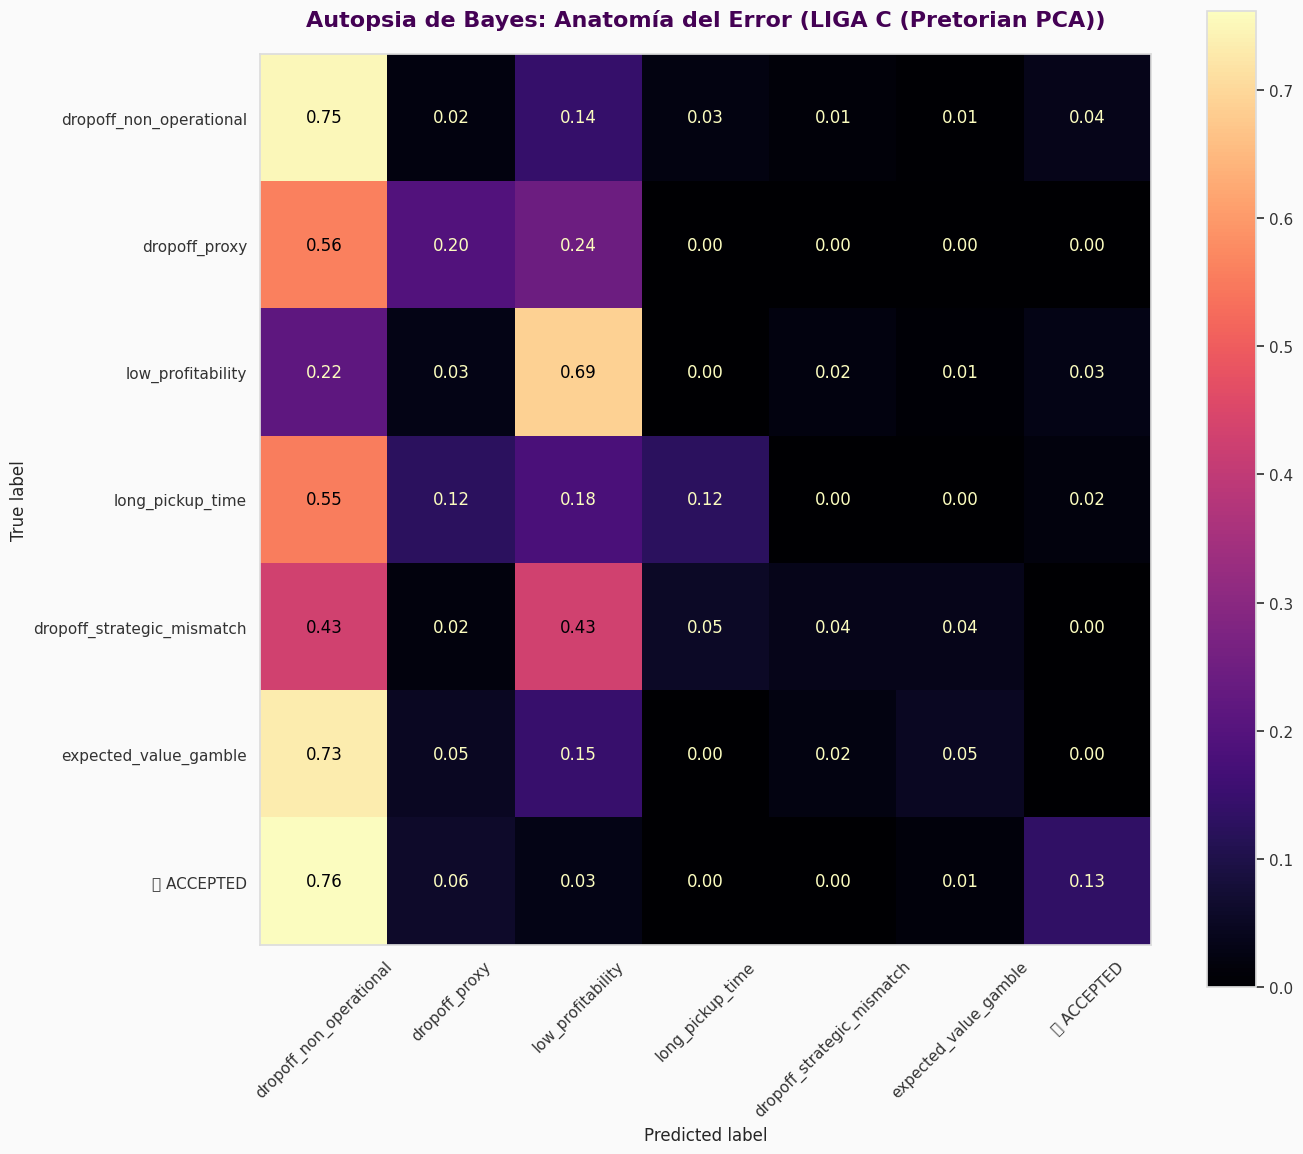


📋 CLASSIFICATION REPORT (Final Week):
                            precision    recall  f1-score   support

   dropoff_non_operational       0.61      0.75      0.67       391
             dropoff_proxy       0.23      0.20      0.21        41
         low_profitability       0.45      0.69      0.54       128
          long_pickup_time       0.35      0.12      0.18        56
dropoff_strategic_mismatch       0.18      0.04      0.06        56
     expected_value_gamble       0.25      0.05      0.08        41
                ✅ ACCEPTED       0.31      0.13      0.19        67

                  accuracy                           0.53       780
                 macro avg       0.34      0.28      0.28       780
              weighted avg       0.47      0.53      0.48       780



In [15]:
# ==============================================================================
# CELL 3: FORENSIC AUTOPSY (DYNAMIC LABELS & CHAMPION ANALYSIS)
# ==============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DEL CAMPEÓN (Basado en el Veredicto Walk-Forward)
# Ganador por Estabilidad y Eficiencia: LIGA C
X_champion = X_praetorian_pca
name_champion = "LIGA C (Pretorian PCA)"

print(f"🔬 Performing Autopsy on {name_champion}...")

# 2. GENERACIÓN DINÁMICA DE ETIQUETAS (EL PUENTE DB)
# Descargamos el catálogo real para no hardcodear
query_labels = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
df_labels = pd.read_sql(query_labels, db_engine)

# Creamos un diccionario {ID: Descripción}
label_map = dict(zip(df_labels['reason_primary_id'], df_labels['reason_primary_description']))

# Agregamos nuestra etiqueta artificial para Aceptados
label_map[9999] = "✅ ACCEPTED"

# Decodificamos las clases que el LabelEncoder (le) aprendió
# le.classes_ contiene los IDs numéricos [1, 2, 3, ... 9999]
# Mapeamos esos IDs a sus nombres usando el diccionario
decoded_labels = [label_map.get(uid, f"Unknown-{uid}") for uid in le.classes_]

print(f"   -> Labels Loaded: {decoded_labels}")

# 3. SIMULACIÓN DEL ÚLTIMO FOLD (Walk-Forward Final)
train_idx, test_idx = custom_cv_folds[-1]

X_train_fold = X_champion.iloc[train_idx]
y_train_fold = y[train_idx]
X_test_fold = X_champion.iloc[test_idx]
y_test_fold = y[test_idx]

print(f"   -> Training on Weeks 1-5 (n={len(X_train_fold)})")
print(f"   -> Testing on Week 6 (n={len(X_test_fold)})")

# 4. ENTRENAMIENTO Y PREDICCIÓN
model = GaussianNB()
model.fit(X_train_fold, y_train_fold)
y_pred = model.predict(X_test_fold)

# 5. VISUALIZACIÓN DE LA CONFUSIÓN
fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test_fold,
    y_pred,
    display_labels=decoded_labels, # ¡Etiquetas Reales!
    cmap='magma',
    normalize='true', # Muestra porcentajes (Recall) para entender mejor los errores
    ax=ax,
    values_format=".2f",
    xticks_rotation=45
)

plt.title(f"Autopsia de Bayes: Anatomía del Error ({name_champion})", fontsize=16, color=OPUS_PURPLE, pad=20)
plt.grid(False)
plt.tight_layout()
plt.show()

# 6. REPORTE TEXTUAL
print("\n📋 CLASSIFICATION REPORT (Final Week):")
print(classification_report(
    y_test_fold,
    y_pred,
    target_names=decoded_labels,
    zero_division=0
))

In [16]:
# ==============================================================================
# CELL 3.5: STRATEGIC DEBRIEF - THE AUTOPSY OF THE INNOCENT
# ==============================================================================
from IPython.display import display, Markdown

autopsy_report = """
# 🔬 ANÁLISIS FORENSE: Autopsia del Modelo Naive Bayes (LIGA C)

La Matriz de Confusión revela una "escena del crimen" fascinante que justifica por qué la estadística simple no puede clonar al experto.

### **1. El Diagnóstico Principal: "El Agujero Negro de la Clase Mayoritaria"**
Observa la **primera columna** (`Predicted: dropoff_non_operational`). Actúa como un pozo gravitacional masivo.
*   **El Hecho:** El modelo predice erróneamente "Zona Prohibida" para:
    *   El **73%** de tus `expected_value_gamble`.
    *   El **76%** de tus `ACCEPTED` (!).
*   **La Causa:** Ante la duda y la falta de fronteras lineales claras, Bayes apuesta por la probabilidad base (50% de los datos son Non-Op).
*   **Veredicto:** **Colapso de Clase.** El modelo no distingue matices, juega a la estadística segura.

### **2. La Tragedia de los Aceptados (Fila Inferior)**
*   **Recall Real:** **0.13** (Solo atrapó al 13% de los viajes buenos).
*   **El Error:** El 76% de las veces, el modelo vio una "Gema" y dijo "Basura".
*   **Significado:** El modelo es **extremadamente pesimista**. Matemáticamente, tus viajes aceptados se parecen demasiado a los rechazos geográficos en este espacio vectorial lineal. Bayes no encuentra la "chispa" no-lineal que te hace decir "Sí".

### **3. El Conflicto: Dinero (Bien) vs. Estrategia (Mal)**
*   **Lo Bueno:** `low_profitability` (Fila 3) tiene un acierto del **69%**.
    *   *Insight:* **Bayes SÍ entiende de dinero.** La señal de "Paga Poco" es fuerte y lineal.
*   **Lo Malo:** `dropoff_strategic_mismatch` (Fila 5) se confunde un 43% de las veces con `low_profitability`.
    *   *Insight:* El modelo no distingue entre "Mal Precio" y "Mala Estrategia". Para él, todo rechazo complejo es solo un problema de dinero.

### **4. La Invisibilidad del Jugador de Póker (`EEUM`)**
*   **Acierto:** **0.05 (5%)**. Prácticamente inexistente.
*   **Insight:** La decisión de "Esperar algo mejor" (Cost of Opportunity) es demasiado compleja para este algoritmo. Requiere contexto temporal secuencial que Bayes ignora.

---

### 🚀 CONCLUSIÓN ESTRATÉGICA PARA FASE II (XGBoost)
Esta autopsia valida científicamente tu arquitectura original:

1.  **Necesidad de la "Cascada Cognitiva":** No podemos mezclar `Non_Op` (el Agujero Negro) con el resto. Debemos filtrar la geografía en la **Capa 1** para que el modelo no se vuelva perezoso.
2.  **Necesidad de No-Linealidad:** La frontera entre `Accepted` y `Non_Op` no es una línea recta. Necesitamos Árboles de Decisión para hacer cortes complejos.
3.  **Mandato de Ponderación:** Es urgente usar `class_weight='balanced'` para forzar al modelo a respetar las clases pequeñas (`EEUM`, `Accepted`) y dejar de obsesionarse con la mayoría.
"""

display(Markdown(autopsy_report))


# 🔬 ANÁLISIS FORENSE: Autopsia del Modelo Naive Bayes (LIGA C)

La Matriz de Confusión revela una "escena del crimen" fascinante que justifica por qué la estadística simple no puede clonar al experto.

### **1. El Diagnóstico Principal: "El Agujero Negro de la Clase Mayoritaria"**
Observa la **primera columna** (`Predicted: dropoff_non_operational`). Actúa como un pozo gravitacional masivo.
*   **El Hecho:** El modelo predice erróneamente "Zona Prohibida" para:
    *   El **73%** de tus `expected_value_gamble`.
    *   El **76%** de tus `ACCEPTED` (!).
*   **La Causa:** Ante la duda y la falta de fronteras lineales claras, Bayes apuesta por la probabilidad base (50% de los datos son Non-Op).
*   **Veredicto:** **Colapso de Clase.** El modelo no distingue matices, juega a la estadística segura.

### **2. La Tragedia de los Aceptados (Fila Inferior)**
*   **Recall Real:** **0.13** (Solo atrapó al 13% de los viajes buenos).
*   **El Error:** El 76% de las veces, el modelo vio una "Gema" y dijo "Basura".
*   **Significado:** El modelo es **extremadamente pesimista**. Matemáticamente, tus viajes aceptados se parecen demasiado a los rechazos geográficos en este espacio vectorial lineal. Bayes no encuentra la "chispa" no-lineal que te hace decir "Sí".

### **3. El Conflicto: Dinero (Bien) vs. Estrategia (Mal)**
*   **Lo Bueno:** `low_profitability` (Fila 3) tiene un acierto del **69%**.
    *   *Insight:* **Bayes SÍ entiende de dinero.** La señal de "Paga Poco" es fuerte y lineal.
*   **Lo Malo:** `dropoff_strategic_mismatch` (Fila 5) se confunde un 43% de las veces con `low_profitability`.
    *   *Insight:* El modelo no distingue entre "Mal Precio" y "Mala Estrategia". Para él, todo rechazo complejo es solo un problema de dinero.

### **4. La Invisibilidad del Jugador de Póker (`EEUM`)**
*   **Acierto:** **0.05 (5%)**. Prácticamente inexistente.
*   **Insight:** La decisión de "Esperar algo mejor" (Cost of Opportunity) es demasiado compleja para este algoritmo. Requiere contexto temporal secuencial que Bayes ignora.

---

### 🚀 CONCLUSIÓN ESTRATÉGICA PARA FASE II (XGBoost)
Esta autopsia valida científicamente tu arquitectura original:

1.  **Necesidad de la "Cascada Cognitiva":** No podemos mezclar `Non_Op` (el Agujero Negro) con el resto. Debemos filtrar la geografía en la **Capa 1** para que el modelo no se vuelva perezoso.
2.  **Necesidad de No-Linealidad:** La frontera entre `Accepted` y `Non_Op` no es una línea recta. Necesitamos Árboles de Decisión para hacer cortes complejos.
3.  **Mandato de Ponderación:** Es urgente usar `class_weight='balanced'` para forzar al modelo a respetar las clases pequeñas (`EEUM`, `Accepted`) y dejar de obsesionarse con la mayoría.


In [17]:
# ==============================================================================
# CELL 4: MISSION DEBRIEF & TRANSITION PROTOCOL
# ==============================================================================
from IPython.display import display, Markdown

conclusion_report = """
# 🏁 CIERRE DE MISIÓN N1: El Establecimiento del Suelo

Hemos concluido el Triatlón Bayesiano. El resultado no es una derrota, es un **Dato de Calibración Crítico**.

### **1. El Baseline Confirmado**
Hemos establecido que un modelo probabilístico simple, operando exclusivamente con variables **físicas y numéricas** (La Guardia Pretoriana), tiene un techo de rendimiento de **F1-Macro ~0.25**. Esto es superior al azar, pero insuficiente para la operación.

### **2. La Limitación Autoimpuesta (Peleando con una mano)**
Es crucial reconocer que este torneo se ejecutó con una desventaja táctica deliberada: **Excluimos todas las variables categóricas.**
*   El modelo "no sabía" en qué zona estaba (`dropoff_polygon_id`).
*   El modelo "no sabía" qué día era (`day_of_week`).
*   Solo veía magnitudes (dinero, tiempo, distancia).

### **3. La Siguiente Frontera: Inyección de Contexto**
La realidad del Agente WiseX no es solo física; es contextual. Saber que estás en *Polanco* un *Viernes* cambia la decisión drásticamente, incluso si la tarifa ($) es idéntica a la de un Lunes en la Roma.

### 🚀 PROTOCOLO DE TRANSICIÓN:
1.  **Clonación:** Duplicaremos esta infraestructura para la siguiente libreta (**Libreta N2**).
2.  **Re-integración:** Levantaremos el veto a las variables categóricas.
3.  **Evolución del Algoritmo:** Pasaremos de la probabilidad (Bayes) a las reglas de corte (**Árboles de Decisión**), que son capaces de digerir este contexto mixto (Numérico + Categórico) para encontrar patrones no lineales.

**Estado:** Libreta N1 Finalizada. Procediendo a la expansión dimensional.
"""

display(Markdown(conclusion_report))


# 🏁 CIERRE DE MISIÓN N1: El Establecimiento del Suelo

Hemos concluido el Triatlón Bayesiano. El resultado no es una derrota, es un **Dato de Calibración Crítico**.

### **1. El Baseline Confirmado**
Hemos establecido que un modelo probabilístico simple, operando exclusivamente con variables **físicas y numéricas** (La Guardia Pretoriana), tiene un techo de rendimiento de **F1-Macro ~0.25**. Esto es superior al azar, pero insuficiente para la operación.

### **2. La Limitación Autoimpuesta (Peleando con una mano)**
Es crucial reconocer que este torneo se ejecutó con una desventaja táctica deliberada: **Excluimos todas las variables categóricas.**
*   El modelo "no sabía" en qué zona estaba (`dropoff_polygon_id`).
*   El modelo "no sabía" qué día era (`day_of_week`).
*   Solo veía magnitudes (dinero, tiempo, distancia).

### **3. La Siguiente Frontera: Inyección de Contexto**
La realidad del Agente WiseX no es solo física; es contextual. Saber que estás en *Polanco* un *Viernes* cambia la decisión drásticamente, incluso si la tarifa ($) es idéntica a la de un Lunes en la Roma.

### 🚀 PROTOCOLO DE TRANSICIÓN:
1.  **Clonación:** Duplicaremos esta infraestructura para la siguiente libreta (**Libreta N2**).
2.  **Re-integración:** Levantaremos el veto a las variables categóricas.
3.  **Evolución del Algoritmo:** Pasaremos de la probabilidad (Bayes) a las reglas de corte (**Árboles de Decisión**), que son capaces de digerir este contexto mixto (Numérico + Categórico) para encontrar patrones no lineales.

**Estado:** Libreta N1 Finalizada. Procediendo a la expansión dimensional.


Porque solo estamos meteiendo las variables numericas? estamos dejando de lado a las vriables categoricas. ERROR GARRAFAL
no se despliegan bien las labels en el grafico.
Clonaré esta libreta y en vez de hacer primero multiclase desde NB hasta XGboost hagamos a la par multiclase con binario..
quero en markdown un buidl que me dio hace unos promots....